# F1 — Drivers Race Performance (1950–2024)

Race-level performance analyses across the full history of F1.
This notebook covers **Section 1** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 1.1a  | Top 10 race winners |
| 1.1b  | Most efficient winners (starts per win) |
| 1.2a  | Top 10 drivers — most podiums |
| 1.2b  | Most efficient podium-getters (starts per podium) |
| 1.3a  | Top 10 drivers — most pole positions |
| 1.3b  | Most efficient qualifiers (starts per pole) |
| 1.4   | Longest consecutive race-win streak |
| 1.5   | Longest consecutive podium streak |
| 1.6   | Top 10 drivers — most fastest laps |
| 1.7   | Drivers with a "perfect weekend" (pole + win + fastest lap) |
| 1.8   | Win rate by starting grid position (P1, P2, P3 …) |
| 1.9   | Top 10 drivers who won without reaching Q2/Q3 |
| 1.10  | Drivers who started last but finished on the podium |
| 1.11  | Drivers who won a race after starting from the pit lane |
| 1.12  | Most frequent race-end statuses (top 10) |


## Setup — imports and data loading

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
qualifying   = pd.read_csv('excel/qualifying.csv')

# Compact display name used everywhere — 'Hamilton L.', 'Verstappen M.'
drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

print('drivers     :', drivers.shape)
print('results     :', results.shape)
print('races       :', races.shape)
print('constructors:', constructors.shape)
print('qualifying  :', qualifying.shape)

drivers     : (861, 10)
results     : (26759, 18)
races       : (1125, 18)
constructors: (212, 5)
qualifying  : (10494, 9)


## Data cleanup — Indianapolis 500 (1950–1960)

The Indy 500 was nominally part of the F1 World Championship from **1950 to 1960** but was a separate American oval race. Most "F1 drivers" appearing in those rows never raced anywhere else in F1, which pollutes per-driver statistics.

Same cleanup as the other notebooks — strip these rows once at the source so every downstream analysis is clean.

In [75]:
# Identify Indy 500 races and drop them from results, qualifying, races
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False),
    'raceId'
]

n_before_results = len(results)

results    = results   [~results   ['raceId'].isin(indy_race_ids)].copy()
qualifying = qualifying[~qualifying['raceId'].isin(indy_race_ids)].copy()
races      = races     [~races     ['raceId'].isin(indy_race_ids)].copy()

print(f'Indy 500 races removed   : {len(indy_race_ids)}')
print(f'Result rows dropped      : {n_before_results - len(results):,}')
print(f'Clean dataset:')
print(f'  races      : {len(races):,}')
print(f'  results    : {len(results):,}')
print(f'  qualifying : {len(qualifying):,}')

# Coerce the `rank` column (= fastest-lap rank in that race) to numeric.
# Ergast stores missing data as the literal string '\N', so a defensive
# pd.to_numeric is needed before any rank == 1 filter will work.
results['rank_num'] = pd.to_numeric(results['rank'], errors='coerce')

Indy 500 races removed   : 11
Result rows dropped      : 405
Clean dataset:
  races      : 1,114
  results    : 26,354
  qualifying : 10,494


## Shared helpers — colors and a streak counter

Same `DECADE_COLORS` palette as the other notebooks (so a driver who debuted in the 1990s shows the same teal across all charts in the project), plus a single `max_streak` helper used by 1.1 and 1.2.

In [76]:
DECADE_COLORS = {
    1950: '#8B2635',  # burgundy
    1960: '#D2691E',  # chocolate orange
    1970: '#DAA520',  # goldenrod
    1980: '#2E8B57',  # sea green
    1990: '#0E7C7B',  # teal
    2000: '#1F4E79',  # navy blue
    2010: '#5B2A86',  # royal purple
    2020: '#3A3A3A',  # dark gray
}


def _hex_to_rgb(hex_color):
    """'#1F4E79' → (0.12, 0.31, 0.47)  — for the luminance check below."""
    h = hex_color.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))


def _luminance(rgb):
    """Perceived brightness 0–1 using ITU-R BT.709 weights."""
    r, g, b = rgb[:3]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def max_streak(condition_series):
    """Length of the longest run of consecutive True values in a boolean series.

    Trick: every time the value flips, increment a 'group' counter via cumsum().
    All consecutive True/False values then share a group id, and the run length
    is just `sum(condition) within group`. Then take the max across True groups.

    Example:
        s     = [F, T, T, T, F, T, T, F]
        flips = [1, 1, 0, 0, 1, 1, 0, 1]
        group = [1, 2, 2, 2, 3, 4, 4, 5]   ← cumsum of flips
        sums per group: {1:0, 2:3, 3:0, 4:2, 5:0} → max = 3
    """
    if not condition_series.any():
        return 0
    groups = (condition_series != condition_series.shift()).cumsum()
    run_lengths = condition_series.groupby(groups).sum()
    return int(run_lengths.max())


# Each driver's debut decade — used to color bars consistently across charts
debut_decade = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .groupby('driverId')['year'].min()
    .pipe(lambda s: (s // 10) * 10)
    .astype(int)
    .to_dict()
)

---
# Section 1 — Drivers Race Performance

### Chart 1.1a — Top 10 race winners

Start with the headline number: career wins.  `positionOrder == 1` summed per driver,
Indy excluded.  Label shows `<wins> / <career race entries>` so you can eyeball who got
more wins in fewer attempts.


Top 10 drivers by career race wins:
       driver  wins  race_entries
  Hamilton L.   105           356
Schumacher M.    91           308
Verstappen M.    63           209
    Vettel S.    53           300
     Prost A.    51           202
     Senna A.    41           162
    Alonso F.    32           404
   Mansell N.    31           192
   Stewart J.    27           100
     Lauda N.    25           174


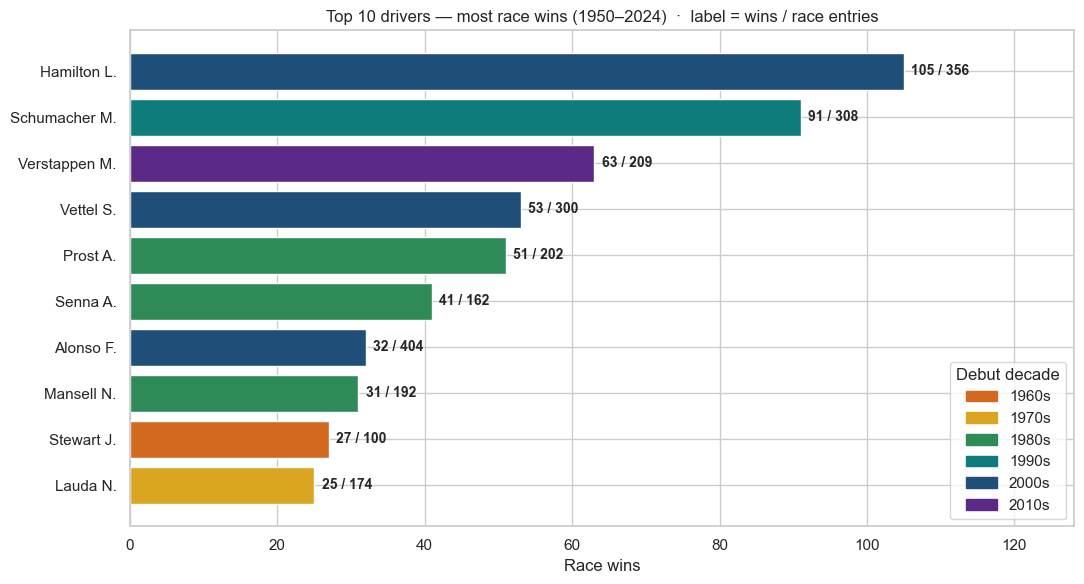

In [77]:
# Career race entries — same denominator we use elsewhere
race_entries = (
    results.groupby('driverId').size()
    .reset_index(name='race_entries')
)

win_counts = (
    results[results['positionOrder'] == 1]
    .groupby('driverId').size()
    .reset_index(name='wins')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
    .sort_values('wins', ascending=False)
    .head(10)
)
win_counts['decade'] = win_counts['driverId'].map(debut_decade)
win_counts = win_counts.sort_values('wins')   # asc → biggest at top after barh

print('Top 10 drivers by career race wins:')
print(win_counts[['driver', 'wins', 'race_entries']]
      .sort_values('wins', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in win_counts['decade']]
plt.barh(range(len(win_counts)), win_counts['wins'], color=bar_colors)
plt.yticks(range(len(win_counts)), win_counts['driver'])

# Label: '<wins> / <race entries>'
for i, row in enumerate(win_counts.itertuples()):
    plt.text(row.wins + 1, i, f'{row.wins} / {row.race_entries}',
             va='center', fontsize=10, fontweight='bold')

used = sorted(win_counts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 10 drivers — most race wins (1950–2024)  ·  label = wins / race entries')
plt.xlabel('Race wins')
plt.ylabel('')
plt.xlim(0, win_counts['wins'].max() * 1.22)
plt.tight_layout()
show_and_save('1.1a_most_wins.png')

### Chart 1.1b — Most efficient winners (starts per win)

The flip side of 1.1a. For every driver with **≥ 5 wins** (otherwise a single fluky win
would top the chart), `starts_per_win = race_entries / wins`. **Lower is better** — Fangio
needed ~3.4 starts per win in the 1950s; modern drivers need ~5–10.

Min-5-wins threshold filters out one-hit wonders without being too strict on shorter careers.

Top 10 most efficient winners (min 5 wins) — starts per win:
       driver  wins  race_entries  starts_per_win
    Fangio J.    24            58            2.42
    Ascari A.    13            35            2.69
     Clark J.    25            73            2.92
Verstappen M.    63           209            3.32
Schumacher M.    91           308            3.38
  Hamilton L.   105           356            3.39
   Stewart J.    27           100            3.70
     Senna A.    41           162            3.95
     Prost A.    51           202            3.96
      Moss S.    16            73            4.56


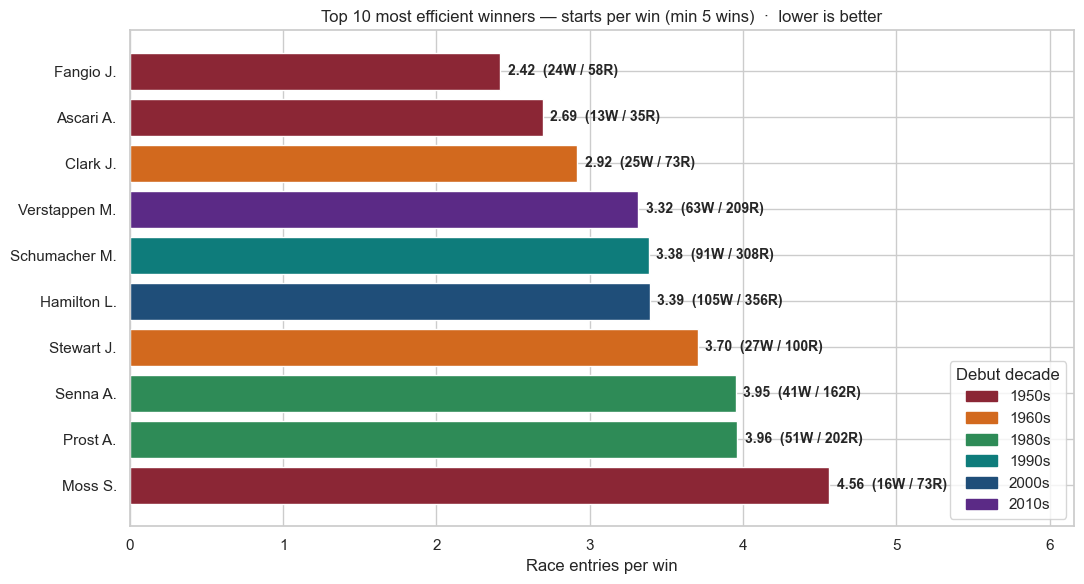

In [78]:
MIN_WINS = 5

# Reuse the per-driver win count from 1.1a's logic, but on the full set (not top 10)
all_wins = (
    results[results['positionOrder'] == 1]
    .groupby('driverId').size()
    .reset_index(name='wins')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
)

efficient_wins = (all_wins[all_wins['wins'] >= MIN_WINS]
                  .assign(starts_per_win=lambda d: d['race_entries'] / d['wins'])
                  .sort_values('starts_per_win')   # smaller = more efficient
                  .head(10))
efficient_wins['decade'] = efficient_wins['driverId'].map(debut_decade)
# Reverse for barh so the best (smallest ratio) ends up at the top
efficient_wins = efficient_wins.sort_values('starts_per_win', ascending=False)

print(f'Top 10 most efficient winners (min {MIN_WINS} wins) — starts per win:')
print(efficient_wins[['driver', 'wins', 'race_entries', 'starts_per_win']]
      .sort_values('starts_per_win')
      .round({'starts_per_win': 2})
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in efficient_wins['decade']]
plt.barh(range(len(efficient_wins)), efficient_wins['starts_per_win'], color=bar_colors)
plt.yticks(range(len(efficient_wins)), efficient_wins['driver'])

# Label: '<ratio>  (<wins>W / <starts>R)'
for i, row in enumerate(efficient_wins.itertuples()):
    plt.text(row.starts_per_win + 0.05, i,
             f'{row.starts_per_win:.2f}  ({row.wins}W / {row.race_entries}R)',
             va='center', fontsize=10, fontweight='bold')

used = sorted(efficient_wins['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title(f'Top 10 most efficient winners — starts per win (min {MIN_WINS} wins)  ·  lower is better')
plt.xlabel('Race entries per win')
plt.ylabel('')
plt.xlim(0, efficient_wins['starts_per_win'].max() * 1.35)
plt.tight_layout()
show_and_save('1.1b_starts_per_win.png')

### Chart 1.2a — Top 10 drivers, most podiums

`positionOrder <= 3`.  No data caveats — podium positions have been recorded reliably
since 1950.  Label shows `<podiums> / <career race entries>`.


Top 10 drivers by podiums (with career race entries):
        driver  podiums  race_entries
   Hamilton L.      202           356
 Schumacher M.      155           308
     Vettel S.      122           300
 Verstappen M.      112           209
     Alonso F.      106           404
      Prost A.      106           202
  Räikkönen K.      103           352
      Senna A.       80           162
Barrichello R.       68           326
     Bottas V.       67           247


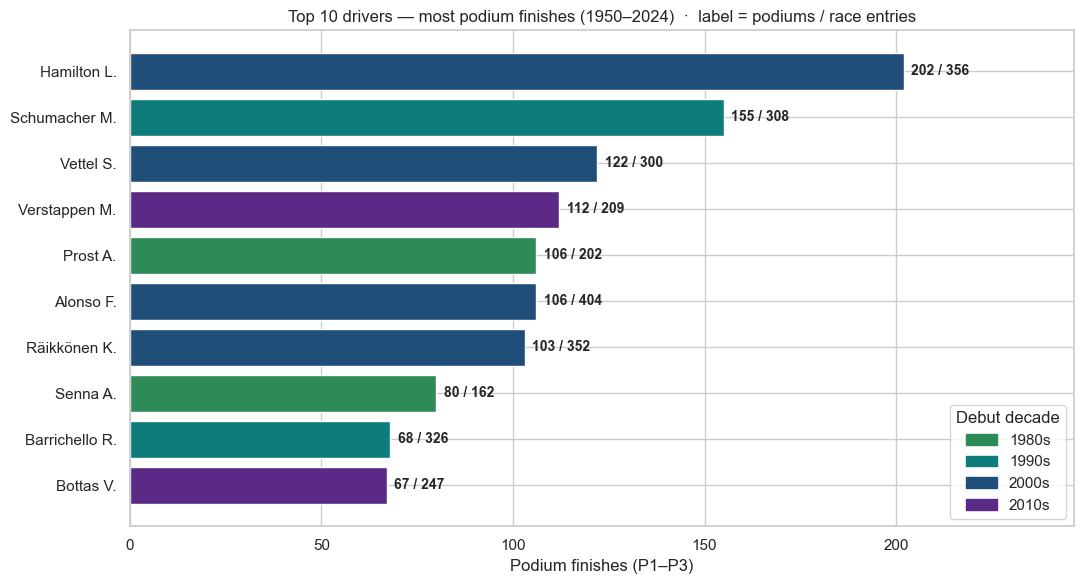

In [79]:
# race_entries (career starts per driver) is defined in 1.1a/1.3a — recompute
# here so this cell still works if those haven't been re-run.
race_entries = (
    results.groupby('driverId').size()
    .reset_index(name='race_entries')
)

podium_counts = (
    results[results['positionOrder'] <= 3]
    .groupby('driverId').size()
    .reset_index(name='podiums')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
    .sort_values('podiums', ascending=False)
    .head(10)
)
podium_counts['decade'] = podium_counts['driverId'].map(debut_decade)
podium_counts = podium_counts.sort_values('podiums')

print('Top 10 drivers by podiums (with career race entries):')
print(podium_counts[['driver', 'podiums', 'race_entries']]
      .sort_values('podiums', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in podium_counts['decade']]
plt.barh(range(len(podium_counts)), podium_counts['podiums'], color=bar_colors)
plt.yticks(range(len(podium_counts)), podium_counts['driver'])

# Label: '<podiums> / <race entries>'
for i, row in enumerate(podium_counts.itertuples()):
    plt.text(row.podiums + 2, i, f'{row.podiums} / {row.race_entries}',
             va='center', fontsize=10, fontweight='bold')

used = sorted(podium_counts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 10 drivers — most podium finishes (1950–2024)  ·  label = podiums / race entries')
plt.xlabel('Podium finishes (P1–P3)')
plt.ylabel('')
plt.xlim(0, podium_counts['podiums'].max() * 1.22)
plt.tight_layout()
show_and_save('1.2a_podiums.png')

### Chart 1.2b — Most efficient podium-getters (starts per podium)

Companion to 1.2a. `starts_per_podium = race_entries / podiums`, with a **≥ 5 podiums**
minimum.  Lower = a higher proportion of races ended in a podium.


Top 10 most efficient podium-getters (min 5 podiums) — starts per podium:
       driver  podiums  race_entries  starts_per_podium
   Fagioli L.        6             8               1.33
    Fangio J.       35            58               1.66
  Hamilton L.      202           356               1.76
    Farina N.       20            37               1.85
Verstappen M.      112           209               1.87
     Prost A.      106           202               1.91
  González J.       15            29               1.93
Schumacher M.      155           308               1.99
     Senna A.       80           162               2.02
    Ascari A.       17            35               2.06


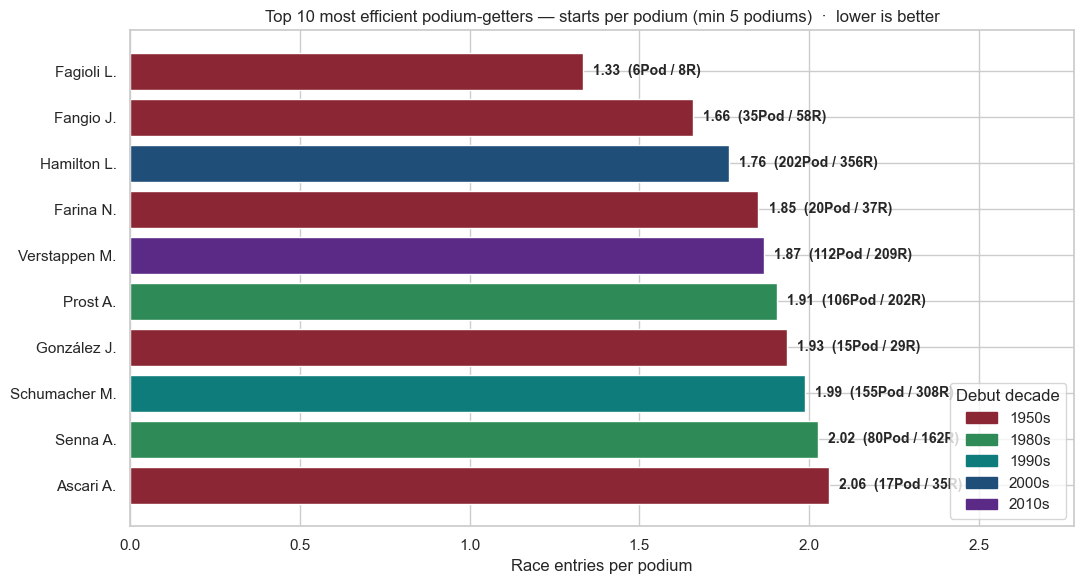

In [80]:
MIN_PODIUMS = 5

all_podiums = (
    results[results['positionOrder'] <= 3]
    .groupby('driverId').size()
    .reset_index(name='podiums')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
)

efficient_podiums = (all_podiums[all_podiums['podiums'] >= MIN_PODIUMS]
                     .assign(starts_per_podium=lambda d: d['race_entries'] / d['podiums'])
                     .sort_values('starts_per_podium')
                     .head(10))
efficient_podiums['decade'] = efficient_podiums['driverId'].map(debut_decade)
efficient_podiums = efficient_podiums.sort_values('starts_per_podium', ascending=False)

print(f'Top 10 most efficient podium-getters (min {MIN_PODIUMS} podiums) — starts per podium:')
print(efficient_podiums[['driver', 'podiums', 'race_entries', 'starts_per_podium']]
      .sort_values('starts_per_podium')
      .round({'starts_per_podium': 2})
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in efficient_podiums['decade']]
plt.barh(range(len(efficient_podiums)),
         efficient_podiums['starts_per_podium'], color=bar_colors)
plt.yticks(range(len(efficient_podiums)), efficient_podiums['driver'])

for i, row in enumerate(efficient_podiums.itertuples()):
    plt.text(row.starts_per_podium + 0.03, i,
             f'{row.starts_per_podium:.2f}  ({row.podiums}Pod / {row.race_entries}R)',
             va='center', fontsize=10, fontweight='bold')

used = sorted(efficient_podiums['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title(f'Top 10 most efficient podium-getters — starts per podium (min {MIN_PODIUMS} podiums)  ·  lower is better')
plt.xlabel('Race entries per podium')
plt.ylabel('')
plt.xlim(0, efficient_podiums['starts_per_podium'].max() * 1.35)
plt.tight_layout()
show_and_save('1.2b_starts_per_podium.png')

### Chart 1.3a — Top 10 drivers, most pole positions

Pole = `grid == 1` in `results`. **We deliberately do not use `qualifying.csv` for this** —
it only goes back to 1994, so it would silently drop ~44 years of pole data.
`results.grid == 1` works for the entire F1 history.  Label shows `<poles> / <starts>`.


Top 10 drivers by pole positions (with career race entries):
       driver  poles  race_entries
  Hamilton L.    104           356
Schumacher M.     68           308
     Senna A.     65           162
    Vettel S.     57           300
Verstappen M.     40           209
     Clark J.     34            73
     Prost A.     33           202
   Mansell N.     32           192
   Rosberg N.     30           206
    Fangio J.     29            58


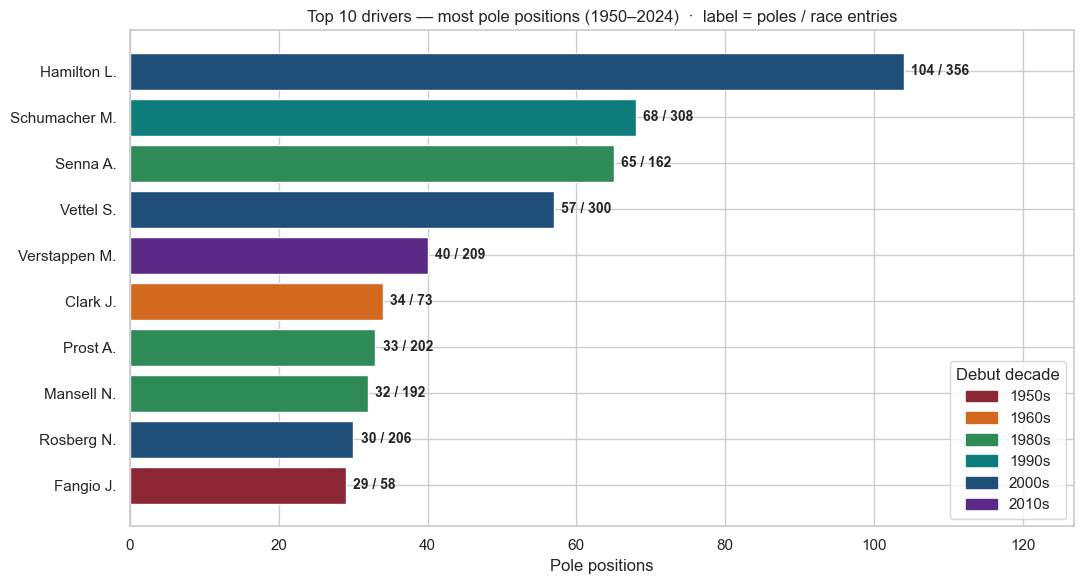

In [81]:
# Career race entries per driver — used as a denominator next to the pole count
race_entries = (
    results.groupby('driverId').size()
    .reset_index(name='race_entries')
)

pole_counts = (
    results[results['grid'] == 1]
    .groupby('driverId').size()
    .reset_index(name='poles')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
    .sort_values('poles', ascending=False)
    .head(10)
)
pole_counts['decade'] = pole_counts['driverId'].map(debut_decade)
pole_counts = pole_counts.sort_values('poles')   # asc → biggest at top after barh

print('Top 10 drivers by pole positions (with career race entries):')
print(pole_counts[['driver', 'poles', 'race_entries']]
      .sort_values('poles', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in pole_counts['decade']]
plt.barh(range(len(pole_counts)), pole_counts['poles'], color=bar_colors)
plt.yticks(range(len(pole_counts)), pole_counts['driver'])

# Label: '<poles> / <race entries>'  e.g. '104 / 350'
for i, row in enumerate(pole_counts.itertuples()):
    plt.text(row.poles + 1, i, f'{row.poles} / {row.race_entries}',
             va='center', fontsize=10, fontweight='bold')

used = sorted(pole_counts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 10 drivers — most pole positions (1950–2024)  ·  label = poles / race entries')
plt.xlabel('Pole positions')
plt.ylabel('')
plt.xlim(0, pole_counts['poles'].max() * 1.22)
plt.tight_layout()
show_and_save('1.3a_pole_positions.png')

### Chart 1.3b — Most efficient qualifiers (starts per pole)

Companion to 1.3a. `starts_per_pole = race_entries / poles`, with a **≥ 5 poles** minimum
so a single fluky pole doesn't dominate.  Lower = a higher proportion of weekends ended in pole.


Top 10 most efficient qualifiers (min 5 poles) — starts per pole:
       driver  poles  race_entries  starts_per_pole
    Fangio J.     29            58             2.00
     Clark J.     34            73             2.15
     Senna A.     65           162             2.49
    Ascari A.     14            35             2.50
  Hamilton L.    104           356             3.42
      Moss S.     17            73             4.29
Schumacher M.     68           308             4.53
Verstappen M.     40           209             5.22
    Vettel S.     57           300             5.26
   Leclerc C.     26           149             5.73


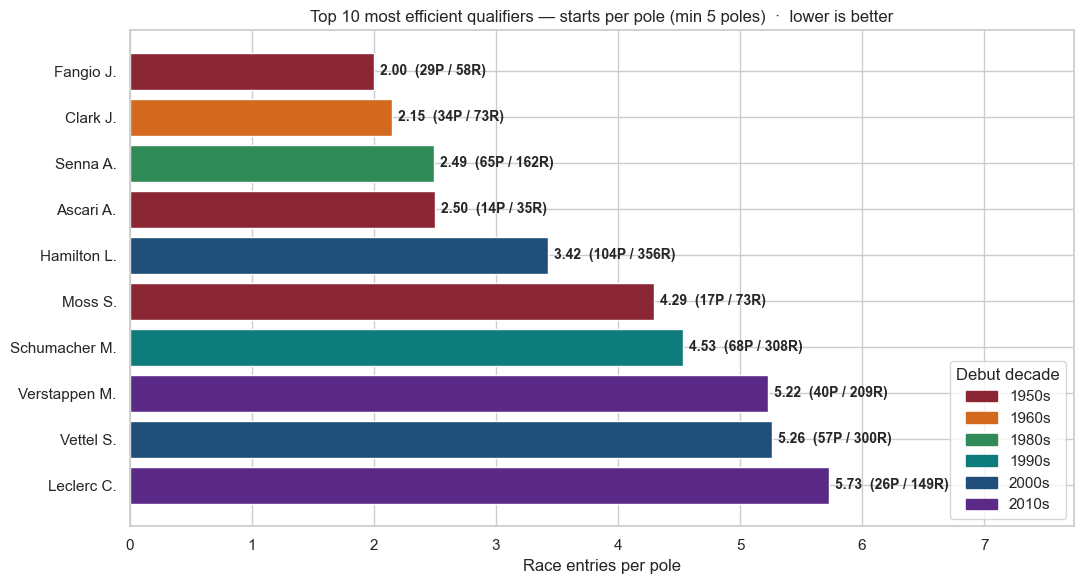

In [82]:
MIN_POLES = 5

all_poles = (
    results[results['grid'] == 1]
    .groupby('driverId').size()
    .reset_index(name='poles')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(race_entries, on='driverId')
)

efficient_poles = (all_poles[all_poles['poles'] >= MIN_POLES]
                   .assign(starts_per_pole=lambda d: d['race_entries'] / d['poles'])
                   .sort_values('starts_per_pole')
                   .head(10))
efficient_poles['decade'] = efficient_poles['driverId'].map(debut_decade)
efficient_poles = efficient_poles.sort_values('starts_per_pole', ascending=False)

print(f'Top 10 most efficient qualifiers (min {MIN_POLES} poles) — starts per pole:')
print(efficient_poles[['driver', 'poles', 'race_entries', 'starts_per_pole']]
      .sort_values('starts_per_pole')
      .round({'starts_per_pole': 2})
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in efficient_poles['decade']]
plt.barh(range(len(efficient_poles)), efficient_poles['starts_per_pole'], color=bar_colors)
plt.yticks(range(len(efficient_poles)), efficient_poles['driver'])

for i, row in enumerate(efficient_poles.itertuples()):
    plt.text(row.starts_per_pole + 0.05, i,
             f'{row.starts_per_pole:.2f}  ({row.poles}P / {row.race_entries}R)',
             va='center', fontsize=10, fontweight='bold')

used = sorted(efficient_poles['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title(f'Top 10 most efficient qualifiers — starts per pole (min {MIN_POLES} poles)  ·  lower is better')
plt.xlabel('Race entries per pole')
plt.ylabel('')
plt.xlim(0, efficient_poles['starts_per_pole'].max() * 1.35)
plt.tight_layout()
show_and_save('1.3b_starts_per_pole.png')

### Chart 1.4 — Longest consecutive race-win streak

For each driver, sort their entire career chronologically and find the **longest run of
races they won back-to-back** (no non-win in between). Indy excluded; counted across
seasons (a streak can span winters).


Top 15 drivers by longest consecutive race-win streak:
       driver  max_win_streak  year_start  year_end
Verstappen M.            10.0      2023.0    2023.0
    Ascari A.             9.0      1952.0    1953.0
    Vettel S.             9.0      2013.0    2013.0
Schumacher M.             7.0      2004.0    2004.0
   Rosberg N.             7.0      2015.0    2016.0
     Clark J.             6.0      1965.0    1965.0
   Brabham J.             5.0      1960.0    1960.0
  Hamilton L.             5.0      2014.0    2014.0
   Mansell N.             5.0      1992.0    1992.0
      Hill D.             4.0      1995.0    1996.0
    Alonso F.             4.0      2006.0    2006.0
    Fangio J.             4.0      1953.0    1954.0
     Rindt J.             4.0      1970.0    1970.0
     Senna A.             4.0      1988.0    1988.0
    Button J.             4.0      2009.0    2009.0


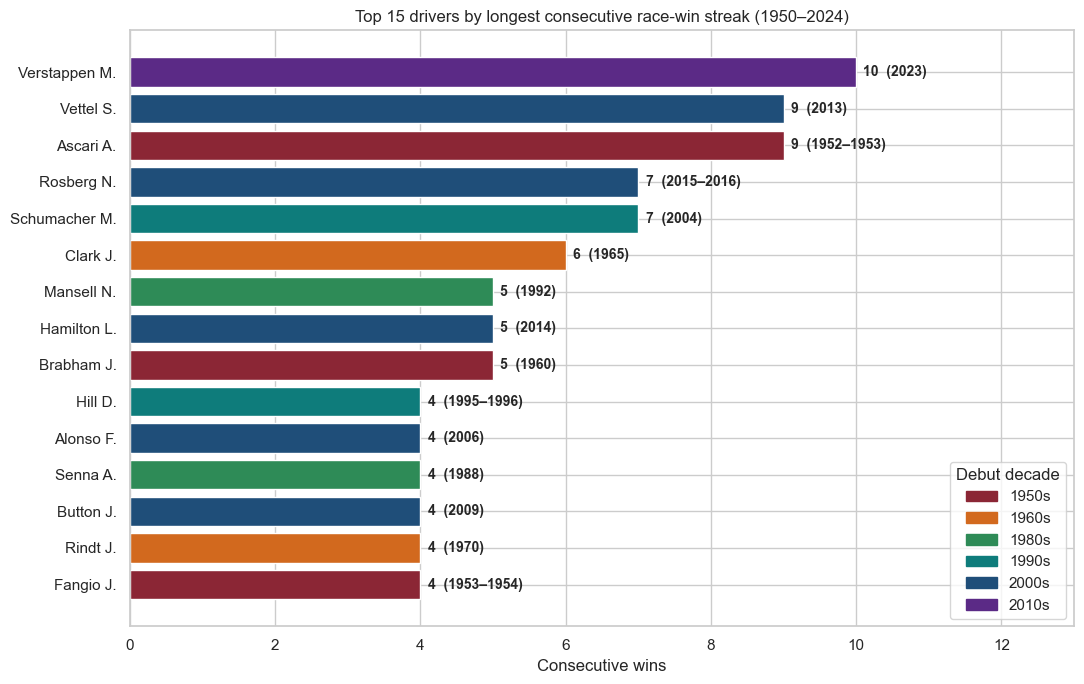

In [83]:
# Step 1 — chronological race history per driver
race_chrono = (
    results[['driverId', 'raceId', 'positionOrder']]
    .merge(races[['raceId', 'year', 'date']], on='raceId')
    .assign(date=lambda d: pd.to_datetime(d['date']))
    .sort_values(['driverId', 'date'])
)

# Step 2 — find each driver's longest win streak AND the years it spanned.
# Trick: tag each row with a 'run_id' that increments on every True/False flip
# (cumsum of the flips). Consecutive wins all share the same run_id, so
# grouping by run_id gives us per-run sizes; the biggest run wins.
def longest_win_year_range(group):
    wins = (group['positionOrder'] == 1)
    if not wins.any():
        return pd.Series({'max_win_streak': 0, 'year_start': None, 'year_end': None})
    run_id = (wins != wins.shift()).cumsum()
    win_rows = group.loc[wins].assign(run_id=run_id[wins])
    sizes = win_rows.groupby('run_id').size()
    best = win_rows[win_rows['run_id'] == sizes.idxmax()]
    return pd.Series({
        'max_win_streak': int(sizes.max()),
        'year_start': int(best['year'].iloc[0]),
        'year_end':   int(best['year'].iloc[-1]),
    })

win_streaks = (
    race_chrono.groupby('driverId', group_keys=False)
    .apply(longest_win_year_range, include_groups=False)
    .reset_index()
    .merge(drivers[['driverId', 'driver']], on='driverId')
)
win_streaks['decade'] = win_streaks['driverId'].map(debut_decade)

top15 = (win_streaks[win_streaks['max_win_streak'] >= 1]
         .sort_values('max_win_streak', ascending=False)
         .head(15)
         .sort_values('max_win_streak'))   # asc → biggest at top after barh

# Pretty year label: '2013' if same year, '2022–2023' if it spanned seasons
def _year_range(start, end):
    s, e = int(start), int(end)
    return f'{s}' if s == e else f'{s}–{e}'

print('Top 15 drivers by longest consecutive race-win streak:')
print(top15[['driver', 'max_win_streak', 'year_start', 'year_end']]
      .sort_values('max_win_streak', ascending=False)
      .to_string(index=False))

# Step 3 — chart
plt.figure(figsize=(11, 7))
bar_colors = [DECADE_COLORS[d] for d in top15['decade']]
plt.barh(range(len(top15)), top15['max_win_streak'], color=bar_colors)
plt.yticks(range(len(top15)), top15['driver'])

# Label each bar with: <streak count>  (<year or year range>)
for i, row in enumerate(top15.itertuples()):
    label = f'{int(row.max_win_streak)}  ({_year_range(row.year_start, row.year_end)})'
    plt.text(row.max_win_streak + 0.1, i, label,
             va='center', fontsize=10, fontweight='bold')

used = sorted(top15['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 15 drivers by longest consecutive race-win streak (1950–2024)')
plt.xlabel('Consecutive wins')
plt.ylabel('')
# More headroom so the year-range label fits without being clipped
plt.xlim(0, top15['max_win_streak'].max() * 1.30)
plt.tight_layout()
show_and_save('1.4_longest_win_streak.png')

**SQL equivalent** (run-length encoding via window function)
```sql
-- 1.4: Longest consecutive race-win streak per driver (Indy excluded)
WITH chrono AS (
    SELECT  r.driverId, ra.date, r.positionOrder,
            ROW_NUMBER() OVER (PARTITION BY r.driverId ORDER BY ra.date) AS race_num
    FROM    results r
    JOIN    races   ra ON r.raceId = ra.raceId
    WHERE   ra.name NOT LIKE '%Indianapolis%'
),
flagged AS (
    SELECT  *,
            CASE WHEN positionOrder = 1 THEN 1 ELSE 0 END AS is_win,
            -- run-length trick: subtract a sequential index from the win index
            race_num - ROW_NUMBER() OVER (PARTITION BY driverId, (positionOrder = 1)
                                          ORDER BY race_num) AS grp
    FROM    chrono
)
SELECT   d.surname || ' ' || SUBSTR(d.forename,1,1) || '.' AS driver,
         MAX(streak)                                        AS max_win_streak
FROM    (SELECT driverId, grp, COUNT(*) AS streak
         FROM   flagged WHERE is_win = 1
         GROUP  BY driverId, grp) s
JOIN     drivers d ON s.driverId = d.driverId
GROUP    BY s.driverId
ORDER    BY max_win_streak DESC
LIMIT    15;
```

### Chart 1.5 — Longest consecutive podium streak

Same algorithm as 1.4, only the boolean changes from `positionOrder == 1` to
`positionOrder <= 3`.  Podium streaks are usually 2–3× longer than win streaks —
being good enough to finish top 3 every race is easier than winning every race.


Top 15 drivers by longest consecutive podium streak:
          driver  max_podium_streak  year_start  year_end
   Schumacher M.               19.0      2001.0    2002.0
     Hamilton L.               16.0      2014.0    2015.0
       Alonso F.               15.0      2005.0    2006.0
   Verstappen M.               15.0      2022.0    2023.0
       Vettel S.               11.0      2010.0    2011.0
      Rosberg N.                9.0      2015.0    2015.0
       Piquet N.                9.0      1987.0    1987.0
        Clark J.                9.0      1963.0    1963.0
        Lauda N.                9.0      1975.0    1976.0
       Ascari A.                9.0      1952.0    1953.0
    Reutemann C.                8.0      1980.0    1981.0
        Senna A.                8.0      1988.0    1988.0
Pablo Montoya J.                8.0      2003.0    2003.0
  Barrichello R.                7.0      2004.0    2004.0
       Button J.                7.0      2009.0    2009.0


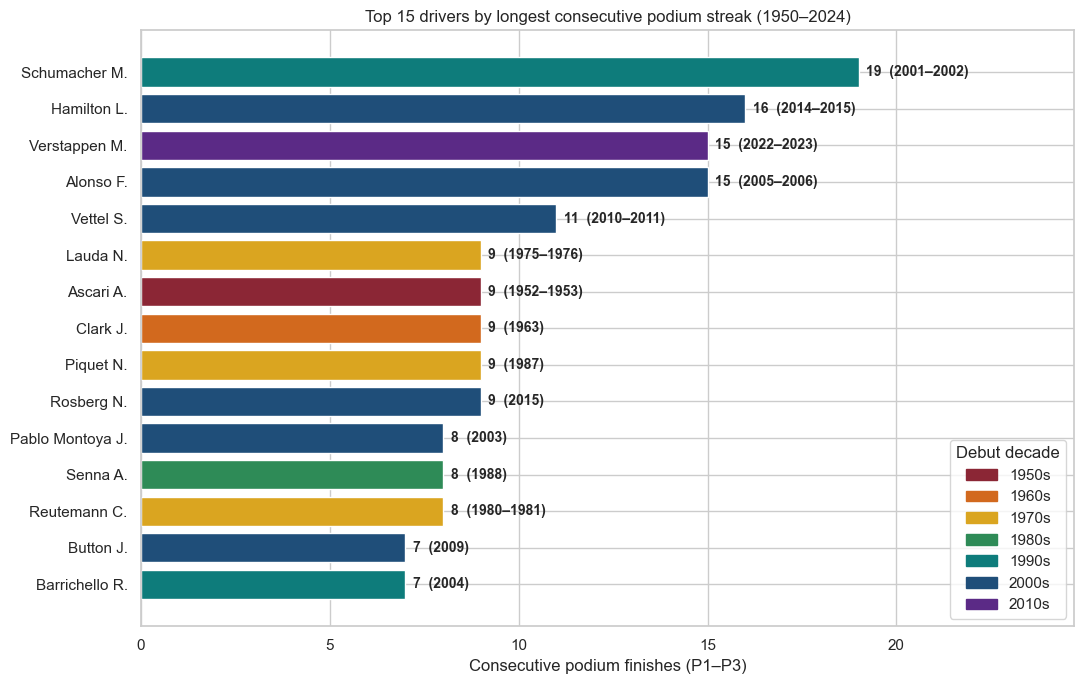

In [84]:
# Same run_id trick as 1.4, but the "good" event is positionOrder <= 3 (podium)
def longest_podium_year_range(group):
    pods = (group['positionOrder'] <= 3)
    if not pods.any():
        return pd.Series({'max_podium_streak': 0, 'year_start': None, 'year_end': None})
    run_id = (pods != pods.shift()).cumsum()
    pod_rows = group.loc[pods].assign(run_id=run_id[pods])
    sizes = pod_rows.groupby('run_id').size()
    best = pod_rows[pod_rows['run_id'] == sizes.idxmax()]
    return pd.Series({
        'max_podium_streak': int(sizes.max()),
        'year_start': int(best['year'].iloc[0]),
        'year_end':   int(best['year'].iloc[-1]),
    })

podium_streaks = (
    race_chrono.groupby('driverId', group_keys=False)
    .apply(longest_podium_year_range, include_groups=False)
    .reset_index()
    .merge(drivers[['driverId', 'driver']], on='driverId')
)
podium_streaks['decade'] = podium_streaks['driverId'].map(debut_decade)

top15_pod = (podium_streaks[podium_streaks['max_podium_streak'] >= 1]
             .sort_values('max_podium_streak', ascending=False)
             .head(15)
             .sort_values('max_podium_streak'))

print('Top 15 drivers by longest consecutive podium streak:')
print(top15_pod[['driver', 'max_podium_streak', 'year_start', 'year_end']]
      .sort_values('max_podium_streak', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(11, 7))
bar_colors = [DECADE_COLORS[d] for d in top15_pod['decade']]
plt.barh(range(len(top15_pod)), top15_pod['max_podium_streak'], color=bar_colors)
plt.yticks(range(len(top15_pod)), top15_pod['driver'])

# Label each bar with: <streak count>  (<year or year range>)
for i, row in enumerate(top15_pod.itertuples()):
    label = f'{int(row.max_podium_streak)}  ({_year_range(row.year_start, row.year_end)})'
    plt.text(row.max_podium_streak + 0.2, i, label,
             va='center', fontsize=10, fontweight='bold')

used = sorted(top15_pod['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 15 drivers by longest consecutive podium streak (1950–2024)')
plt.xlabel('Consecutive podium finishes (P1–P3)')
plt.ylabel('')
plt.xlim(0, top15_pod['max_podium_streak'].max() * 1.30)
plt.tight_layout()
show_and_save('1.5_longest_podium_streak.png')

### Chart 1.6 — Top 10 drivers, most fastest laps *(2004 onward)*

`rank == 1` in `results` means the driver set the fastest race lap in that race.

**Restricted to 2004 onward** — the `rank` column only has reliable data from 2004. Pre-2004 races mostly store `\N` for `rank`, so a "Schumacher fastest-lap count" before 2004 isn't really computable from this dataset. Comparing apples-to-apples within the modern era is fairer than mixing data sources.

Top 10 drivers by fastest laps (2004 onward), with active year range:
       driver  fastest_laps  year_first  year_last
  Hamilton L.            66        2007       2024
 Räikkönen K.            42        2004       2018
    Vettel S.            38        2009       2019
Verstappen M.            33        2016       2024
    Alonso F.            25        2005       2024
Schumacher M.            21        2004       2012
   Rosberg N.            20        2006       2016
    Webber M.            19        2009       2013
    Bottas V.            19        2014       2021
 Ricciardo D.            17        2014       2024


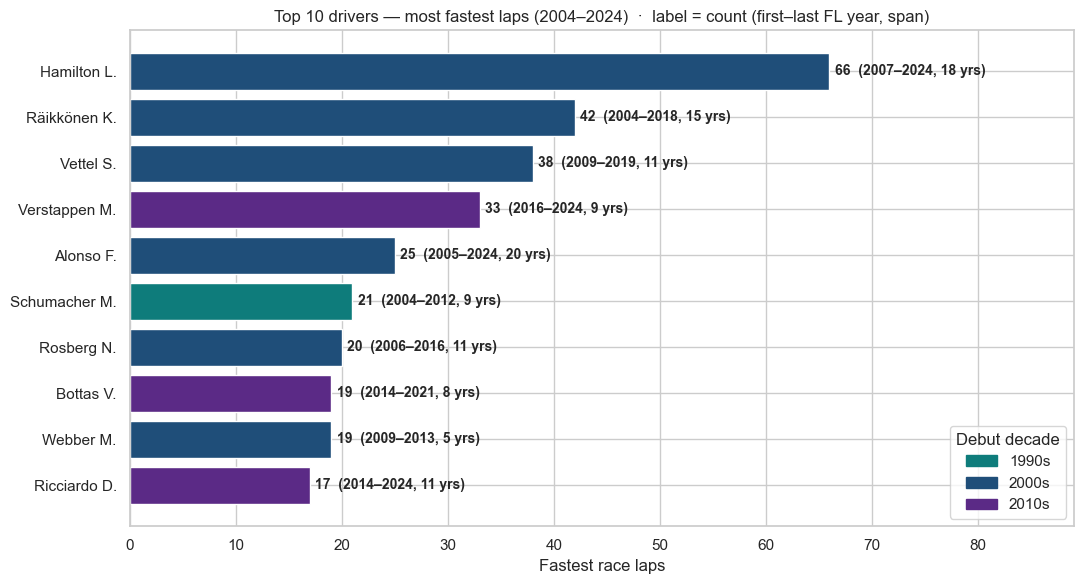

In [85]:
# Filter to 2004+ where the rank column is reliably populated
results_2004plus = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .query('year >= 2004')
)

# Active fastest-lap range per driver: year of their first FL → year of their last FL
fl_rows = results_2004plus[results_2004plus['rank_num'] == 1]
fl_year_range = (
    fl_rows.groupby('driverId')['year']
    .agg(year_first='min', year_last='max')
    .reset_index()
)

fl_counts = (
    fl_rows.groupby('driverId').size()
    .reset_index(name='fastest_laps')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(fl_year_range, on='driverId')
    .sort_values('fastest_laps', ascending=False)
    .head(10)
)
fl_counts['decade'] = fl_counts['driverId'].map(debut_decade)
fl_counts = fl_counts.sort_values('fastest_laps')

print('Top 10 drivers by fastest laps (2004 onward), with active year range:')
print(fl_counts[['driver', 'fastest_laps', 'year_first', 'year_last']]
      .sort_values('fastest_laps', ascending=False)
      .to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in fl_counts['decade']]
plt.barh(range(len(fl_counts)), fl_counts['fastest_laps'], color=bar_colors)
plt.yticks(range(len(fl_counts)), fl_counts['driver'])

# Label: '<count>  (<first>–<last>, N yrs)' — span is inclusive
for i, row in enumerate(fl_counts.itertuples()):
    span = int(row.year_last) - int(row.year_first) + 1
    yr = _year_range(row.year_first, row.year_last)
    plt.text(row.fastest_laps + 0.5, i, f'{row.fastest_laps}  ({yr}, {span} yrs)',
             va='center', fontsize=10, fontweight='bold')

used = sorted(fl_counts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 10 drivers — most fastest laps (2004–2024)  ·  label = count (first–last FL year, span)')
plt.xlabel('Fastest race laps')
plt.ylabel('')
plt.xlim(0, fl_counts['fastest_laps'].max() * 1.35)
plt.tight_layout()
show_and_save('1.6_fastest_laps.png')

### Chart 1.7 — "Perfect weekend" (pole + win + fastest lap) *(2004 onward)*

A driver-race where **all three** happen: started P1 (`grid == 1`), finished P1 (`positionOrder == 1`), set the fastest race lap (`rank == 1`).

**Restricted to 2004 onward** for the same reason as 1.6 — fastest-lap rank isn't reliable before then, so a "perfect weekend" can't be properly verified for earlier eras.

Two views: (a) total perfect weekends per driver (top 10), (b) every individual perfect weekend (table).

Total perfect weekends (pole + win + fastest lap), 2004 onward: 69

Every perfect weekend:
 year                        gp         driver     team
 2004        Spanish Grand Prix  Schumacher M.  Ferrari
 2004     Australian Grand Prix  Schumacher M.  Ferrari
 2004        Bahrain Grand Prix  Schumacher M.  Ferrari
 2004       European Grand Prix  Schumacher M.  Ferrari
 2004      Hungarian Grand Prix  Schumacher M.  Ferrari
 2004        Italian Grand Prix Barrichello R.  Ferrari
 2006         French Grand Prix  Schumacher M.  Ferrari
 2006  United States Grand Prix  Schumacher M.  Ferrari
 2006        British Grand Prix      Alonso F.  Renault
 2007     Australian Grand Prix   Räikkönen K.  Ferrari
 2007        Italian Grand Prix      Alonso F.  McLaren
 2007       Japanese Grand Prix    Hamilton L.  McLaren
 2007         Monaco Grand Prix      Alonso F.  McLaren
 2007        Bahrain Grand Prix       Massa F.  Ferrari
 2007        Spanish Grand Prix       Massa F.  Ferrari
 2008        

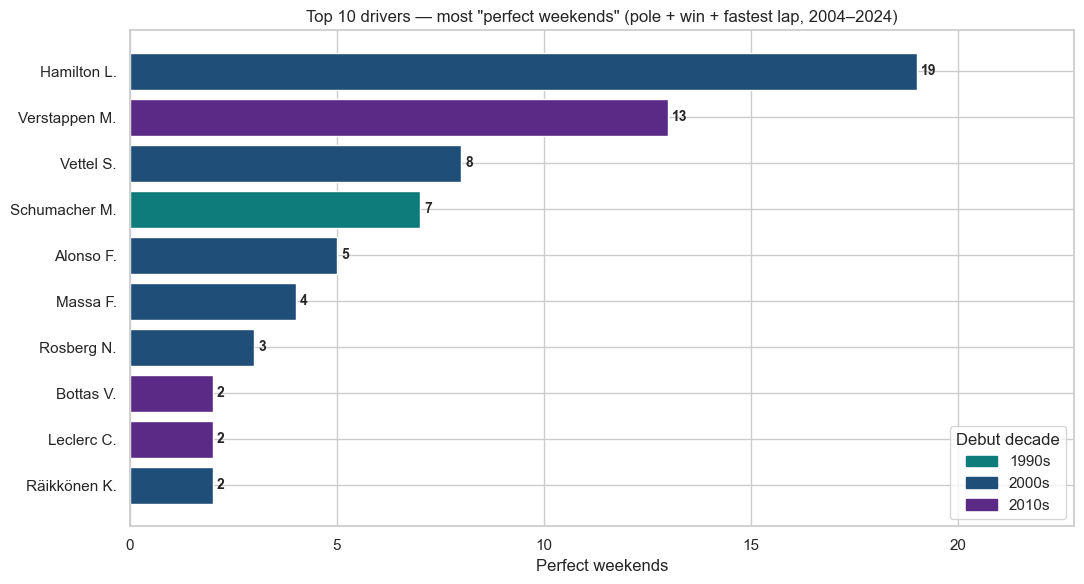

In [86]:
perfect = (
    results[(results['grid'] == 1) &
            (results['positionOrder'] == 1) &
            (results['rank_num'] == 1)]
    .merge(races[['raceId', 'year', 'name']].rename(columns={'name': 'gp'}), on='raceId')
    .query('year >= 2004')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(constructors[['constructorId', 'name']].rename(columns={'name': 'team'}),
           on='constructorId')
    .sort_values(['year'])
)

print(f'Total perfect weekends (pole + win + fastest lap), 2004 onward: {len(perfect)}')
print()
print('Every perfect weekend:')
print(perfect[['year', 'gp', 'driver', 'team']].to_string(index=False))

# View A — count per driver
pw_counts = (perfect.groupby('driverId')
             .agg(perfect_weekends=('raceId', 'count'))
             .reset_index()
             .merge(drivers[['driverId', 'driver']], on='driverId')
             .sort_values('perfect_weekends', ascending=False)
             .head(10))
pw_counts['decade'] = pw_counts['driverId'].map(debut_decade)
pw_counts = pw_counts.sort_values('perfect_weekends')

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in pw_counts['decade']]
plt.barh(range(len(pw_counts)), pw_counts['perfect_weekends'], color=bar_colors)
plt.yticks(range(len(pw_counts)), pw_counts['driver'])

for i, row in enumerate(pw_counts.itertuples()):
    plt.text(row.perfect_weekends + 0.1, i, str(row.perfect_weekends),
             va='center', fontsize=10, fontweight='bold')

used = sorted(pw_counts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.title('Top 10 drivers — most "perfect weekends" (pole + win + fastest lap, 2004–2024)')
plt.xlabel('Perfect weekends')
plt.ylabel('')
plt.xlim(0, pw_counts['perfect_weekends'].max() * 1.20)
plt.tight_layout()
show_and_save('1.7_perfect_weekends.png')

### Chart 1.8 — Win rate by starting grid position

For each grid slot from P1 to P24, what fraction of starts ended in a race win? `grid == 0` is a pit-lane start (covered separately in 1.11). `grid > 24` is a sporadic 1960s thing (some races had 26+ cars) — clipped out so the bar chart isn't dominated by single-event noise.

Win rate by starting grid position:
 grid  starts  wins  win_rate_pct
    1    1125   479     42.577778
    2    1112   266     23.920863
    3    1118   137     12.254025
    4    1119    68      6.076854
    5    1120    48      4.285714
    6    1112    39      3.507194
    7    1121    21      1.873327
    8    1115    17      1.524664
    9    1119     5      0.446828
   10    1115    12      1.076233
   11    1120     5      0.446429
   12    1116     3      0.268817
   13    1114     3      0.269300
   14    1107     6      0.542005
   15    1102     1      0.090744
   16    1088     2      0.183824
   17    1076     3      0.278810
   18    1037     1      0.096432
   19    1019     0      0.000000
   20     964     0      0.000000
   21     686     0      0.000000
   22     645     1      0.155039
   23     441     0      0.000000
   24     418     0      0.000000


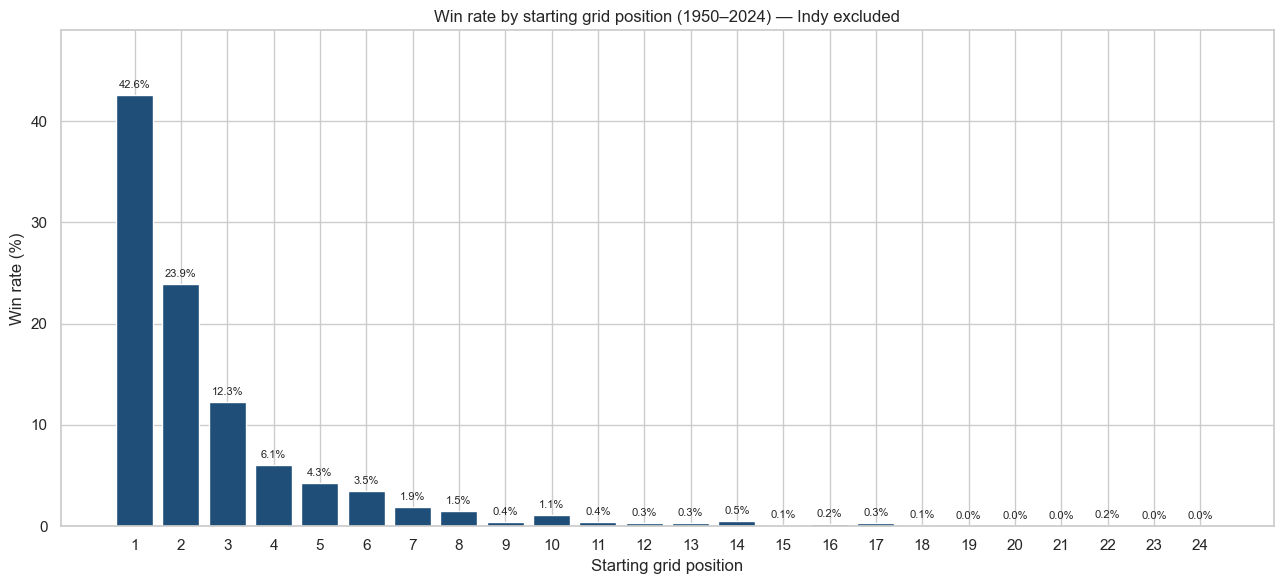

In [87]:
grid_stats = (
    results[(results['grid'] >= 1) & (results['grid'] <= 24)]
    .groupby('grid')
    .agg(starts=('raceId', 'count'),
         wins=('positionOrder', lambda p: (p == 1).sum()))
    .reset_index()
)
grid_stats['win_rate_pct'] = grid_stats['wins'] / grid_stats['starts'] * 100

print('Win rate by starting grid position:')
print(grid_stats.to_string(index=False))

plt.figure(figsize=(13, 6))
bars = plt.bar(grid_stats['grid'], grid_stats['win_rate_pct'],
               color='#1F4E79', edgecolor='white')

for bar, row in zip(bars, grid_stats.itertuples()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{row.win_rate_pct:.1f}%',
             ha='center', va='bottom', fontsize=8)

plt.title('Win rate by starting grid position (1950–2024) — Indy excluded')
plt.xlabel('Starting grid position')
plt.ylabel('Win rate (%)')
plt.xticks(grid_stats['grid'])
plt.ylim(0, grid_stats['win_rate_pct'].max() * 1.15)
plt.tight_layout()
show_and_save('1.8_win_rate_by_grid.png')

**Winners from the back of the grid (P14–P24)**

- **P14** (6 wins, the busiest back-of-grid slot)
  - 1977 Jones — Austrian GP
  - 1996 Panis — Monaco GP
  - 1999 Herbert — European GP (Nürburgring)
  - 2006 Button — Hungarian GP
  - 2018 Hamilton — German GP (Hockenheim)
  - 2022 Verstappen — Belgian GP (Spa)
- **P15**
  - 2008 Alonso — Singapore GP
- **P16**
  - 1973 Stewart — South African GP (Kyalami)
  - 1995 Schumacher — Belgian GP (Spa)
- **P17**
  - 1982 Watson — Detroit GP
  - 2005 Räikkönen — Japanese GP (Suzuka)
  - 2024 Verstappen — São Paulo GP (Interlagos)
- **P18**
  - 2000 Barrichello — German GP (Hockenheim)
- **P22**
  - 1983 Watson — United States GP West (Long Beach) — F1's deepest grid-position win


### Chart 1.9 — Top 10 drivers who won without reaching Q2/Q3

Q1/Q2/Q3 elimination format started in 2006. A driver "didn't reach Q2" if their `qualifying` row has a Q1 time but Q2 is `\N` (eliminated in Q1). Same for Q3.

We count race wins where the driver was eliminated in Q1 OR Q2 — i.e., they never reached the Q3 pole-shootout — yet still won the race. Almost always means a wet race + smart strategy + chaos.

Note: results before 2006 are excluded (Q1/Q2/Q3 format didn't exist).

Race wins where the winner did NOT reach Q2: 2
Race wins where the winner did NOT reach Q3: 6

Top 10 drivers who won without reaching Q3:
       driver  wins_no_q3                          events
  Hamilton L.           2 2015 United States; 2018 German
    Alonso F.           2   2008 Singapore; 2012 European
Verstappen M.           2      2023 Miami; 2024 São Paulo


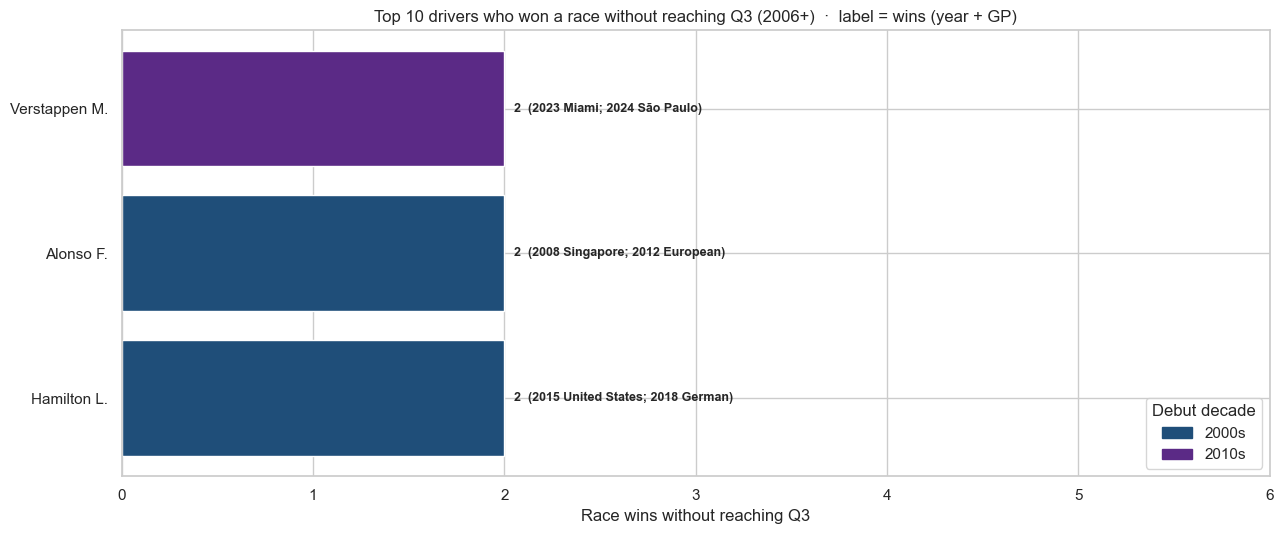

In [88]:
# Step 1 — merge qualifying with results, restrict to 2006+ (Q1/Q2/Q3 era)
qual_results = (
    qualifying[['raceId', 'driverId', 'q1', 'q2', 'q3']]
    .merge(results[['raceId', 'driverId', 'positionOrder']],
           on=['raceId', 'driverId'])
    .merge(races[['raceId', 'year', 'name']].rename(columns={'name': 'gp'}),
           on='raceId')
    .query('year >= 2006')
)

# Step 2 — Ergast stores missing qualifying times as the literal string '\N'.
# Convert NaN/'\N' to a single 'reached' boolean per session.
def reached(col):
    return col.fillna('\\N').astype(str).str.replace('\\N', '').str.len() > 0

qual_results['reached_q2'] = reached(qual_results['q2'])
qual_results['reached_q3'] = reached(qual_results['q3'])

# Step 3 — winners who never made it past Q1 (no Q2 time at all)
won_without_q2 = qual_results[(qual_results['positionOrder'] == 1) &
                              (~qual_results['reached_q2'])]
# Or won despite missing Q3 (made Q2 but bombed out before Q3)
won_without_q3 = qual_results[(qual_results['positionOrder'] == 1) &
                              (~qual_results['reached_q3'])]

print(f'Race wins where the winner did NOT reach Q2: {len(won_without_q2)}')
print(f'Race wins where the winner did NOT reach Q3: {len(won_without_q3)}')

# Aggregate per driver: count + concatenated "year GP" list for the labels.
# Shorten 'Grand Prix' → 'GP' so labels don't overflow the chart.
won_q3_with_gp = (won_without_q3
                  .assign(gp_short=lambda d: d['gp'].str.replace(' Grand Prix', '', regex=False))
                  .sort_values('year'))

agg_win_no_q3 = (won_q3_with_gp
                 .groupby('driverId')
                 .agg(wins_no_q3=('raceId', 'count'),
                      events=('gp_short',
                              lambda s, _years=won_q3_with_gp['year']:
                              '; '.join(f'{y} {g}' for y, g
                                        in zip(_years.loc[s.index], s))))
                 .reset_index()
                 .merge(drivers[['driverId', 'driver']], on='driverId')
                 .sort_values('wins_no_q3', ascending=False)
                 .head(10))
agg_win_no_q3['decade'] = agg_win_no_q3['driverId'].map(debut_decade)
agg_win_no_q3 = agg_win_no_q3.sort_values('wins_no_q3')

print('\nTop 10 drivers who won without reaching Q3:')
print(agg_win_no_q3[['driver', 'wins_no_q3', 'events']]
      .sort_values('wins_no_q3', ascending=False)
      .to_string(index=False))

if len(agg_win_no_q3) == 0:
    print('\n(No drivers in the top 10 — Q3 has been very deterministic post-2006.)')
else:
    plt.figure(figsize=(13, 5.5))
    bar_colors = [DECADE_COLORS[d] for d in agg_win_no_q3['decade']]
    plt.barh(range(len(agg_win_no_q3)),
             agg_win_no_q3['wins_no_q3'], color=bar_colors)
    plt.yticks(range(len(agg_win_no_q3)), agg_win_no_q3['driver'])

    # Label each bar with: <count>  (<year GP>; <year GP>; …)
    for i, row in enumerate(agg_win_no_q3.itertuples()):
        plt.text(row.wins_no_q3 + 0.05, i,
                 f'{row.wins_no_q3}  ({row.events})',
                 va='center', fontsize=9, fontweight='bold')

    used = sorted(agg_win_no_q3['decade'].unique())
    handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
               for d in used]
    plt.legend(handles=handles, title='Debut decade',
               loc='lower right', frameon=True)

    plt.title('Top 10 drivers who won a race without reaching Q3 (2006+)  ·  label = wins (year + GP)')
    plt.xlabel('Race wins without reaching Q3')
    plt.ylabel('')
    # Big right-side headroom — the GP-list label is long
    plt.xlim(0, agg_win_no_q3['wins_no_q3'].max() * 3.0)
    plt.tight_layout()
    show_and_save('1.9_wins_without_q3.png')

### Chart 1.10 — Started last but finished on the podium

For each race, find the **maximum grid position** (= the back of the grid for that specific race), then look for any driver who started at that grid slot AND finished P1–P3.

This is rare enough (probably <30 instances ever) that a **table** reads better than a bar chart. Each row gets full context: year, GP, team, grid, finishing position.

In [89]:
# Step 1 — last grid position per race (excludes pit-lane starts where grid=0)
last_grid_per_race = (
    results[results['grid'] > 0]
    .groupby('raceId')['grid'].max()
    .reset_index(name='last_grid')
)

# Step 2 — driver-races where grid == last_grid AND positionOrder <= 3
last_to_podium = (
    results[results['grid'] > 0]
    .merge(last_grid_per_race, on='raceId')
    .query('grid == last_grid and positionOrder <= 3')
    .merge(races[['raceId', 'year', 'name']].rename(columns={'name': 'gp'}),
           on='raceId')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(constructors[['constructorId', 'name']].rename(columns={'name': 'team'}),
           on='constructorId')
    .sort_values('year')
    [['year', 'gp', 'driver', 'team', 'grid', 'positionOrder']]
    .rename(columns={'positionOrder': 'finish'})
)

print(f'Times a driver started LAST and finished on the podium: {len(last_to_podium)}')
print()
print(last_to_podium.to_string(index=False))

Times a driver started LAST and finished on the podium: 15

 year                            gp           driver       team  grid  finish
 1950             French Grand Prix     Whitehead P.    Ferrari    18       3
 1956            Italian Grand Prix     Flockhart R.  Connaught    26       3
 1958             French Grand Prix     von Trips W.    Ferrari    21       3
 1968            Spanish Grand Prix        Redman B. Cooper-BRM    13       3
 1980 United States Grand Prix West    Fittipaldi E. Fittipaldi    24       3
 2005             German Grand Prix Pablo Montoya J.    McLaren    20       2
 2005           Canadian Grand Prix   Barrichello R.    Ferrari    20       3
 2006            Bahrain Grand Prix     Räikkönen K.    McLaren    22       3
 2009         Australian Grand Prix        Trulli J.     Toyota    20       3
 2012          Abu Dhabi Grand Prix        Vettel S.   Red Bull    24       3
 2014          Hungarian Grand Prix      Hamilton L.   Mercedes    22       3
 201

### Chart 1.11 — Won a race after starting from the pit lane

`grid == 0` in `results` = pit-lane start (driver missed qualifying parc fermé rules, suffered a major mechanical, etc.). Combined with `positionOrder == 1` (race winner), this is one of the rarest events in F1 — table format only.

In [90]:
pit_lane_wins = (
    results[(results['grid'] == 0) & (results['positionOrder'] == 1)]
    .merge(races[['raceId', 'year', 'name']].rename(columns={'name': 'gp'}),
           on='raceId')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(constructors[['constructorId', 'name']].rename(columns={'name': 'team'}),
           on='constructorId')
    .sort_values('year')
    [['year', 'gp', 'driver', 'team']]
)

print(f'Race wins from a pit-lane start in F1 history: {len(pit_lane_wins)}')
print()
if len(pit_lane_wins):
    print(pit_lane_wins.to_string(index=False))
else:
    print('(None on record.)')

Race wins from a pit-lane start in F1 history: 0

(None on record.)


### Chart 1.12 — Most frequent race-end statuses (top 10)

What outcomes does an F1 race participation end with? Group every row in
`results` by `statusId`, join `status.csv` to get the human-readable label,
take the top 10 by count.

**Editorial choice — collapse "+N Laps" into one "Lapped" bucket.** The
`status.csv` table splits this outcome across 20+ rows (`+1 Lap`, `+2 Laps`,
`+3 Laps`, …, `+49 Laps`) but they all represent the same outcome: the
driver was classified at the finish but a full lap or more behind. Keeping
them split would mean "+1 Lap" appears mid-chart while the underlying
*lapped* story is fragmented — collapsing them into one bucket gives a
cleaner three-category narrative (lead-lap finish vs lapped vs DNF).

**Caveat — `Did not qualify` / `Did not prequalify` are not race-day
outcomes.** They mean the driver entered the weekend but never made the
grid (mostly 1980s small teams + the prequalifying era 1988–1992). They
still appear in `results.csv` so they're included here as part of the
"what does a race participation end with" story, but they aren't *retirements
during a race* — useful to remember when reading the chart.

The chart uses semantic coloring (green = lead-lap finish, amber = lapped,
burgundy = DNF reason) rather than the project's `DECADE_COLORS` palette,
because the chart has no time dimension — every bar is an aggregate across
the full 1950–2024 range.

Total driver-race rows analysed (Indy-excluded): 26,354

Top 10 race-end statuses (+N Laps merged into "Lapped"):
            status  count  pct
          Finished   7550 28.6
            Lapped   7414 28.1
            Engine   2001  7.6
   Did not qualify   1025  3.9
          Accident   1015  3.9
         Collision    854  3.2
           Gearbox    809  3.1
          Spun off    781  3.0
        Suspension    427  1.6
Did not prequalify    331  1.3


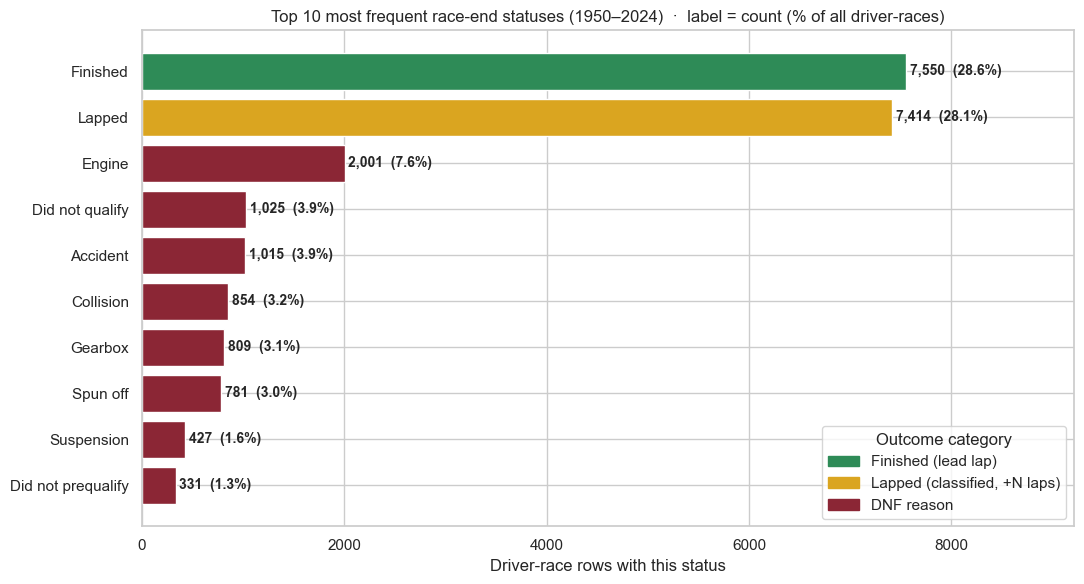

In [91]:
# Editorial bucket: every '+N Laps' status is the same outcome, collapse them
status = pd.read_csv('excel/status.csv')

status_bucketed = status.assign(
    bucket=lambda d: d['status'].where(
        ~d['status'].str.startswith('+'), other='Lapped'
    )
)

status_counts = (
    results.merge(status_bucketed[['statusId', 'bucket']], on='statusId')
    .groupby('bucket').size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)
total_rows = len(results)
status_counts['pct'] = status_counts['count'] / total_rows * 100

# Semantic palette: green = finished, amber = lapped, burgundy = DNF
FINISH_COLOR = '#2E8B57'   # sea green
LAPPED_COLOR = '#DAA520'   # goldenrod
DNF_COLOR    = '#8B2635'   # burgundy


def status_color(s):
    if s == 'Finished':
        return FINISH_COLOR
    if s == 'Lapped':
        return LAPPED_COLOR
    return DNF_COLOR


status_counts['color'] = status_counts['bucket'].apply(status_color)
status_counts = status_counts.sort_values('count')   # asc → biggest at top after barh

print(f'Total driver-race rows analysed (Indy-excluded): {total_rows:,}\n')
print('Top 10 race-end statuses (+N Laps merged into "Lapped"):')
print(status_counts[['bucket', 'count', 'pct']]
      .rename(columns={'bucket': 'status'})
      .sort_values('count', ascending=False)
      .round({'pct': 1})
      .to_string(index=False))

plt.figure(figsize=(11, 6))
plt.barh(range(len(status_counts)),
         status_counts['count'],
         color=status_counts['color'])
plt.yticks(range(len(status_counts)), status_counts['bucket'])

max_count = status_counts['count'].max()
for i, row in enumerate(status_counts.itertuples()):
    plt.text(row.count + max_count * 0.005, i,
             f'{int(row.count):,}  ({row.pct:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=FINISH_COLOR, label='Finished (lead lap)'),
    plt.Rectangle((0, 0), 1, 1, color=LAPPED_COLOR, label='Lapped (classified, +N laps)'),
    plt.Rectangle((0, 0), 1, 1, color=DNF_COLOR,    label='DNF reason'),
]
plt.legend(handles=handles, title='Outcome category',
           loc='lower right', frameon=True)

plt.title('Top 10 most frequent race-end statuses (1950–2024)  ·  label = count (% of all driver-races)')
plt.xlabel('Driver-race rows with this status')
plt.ylabel('')
plt.xlim(0, max_count * 1.22)
plt.tight_layout()
show_and_save('1.12_status_top10.png')

**SQL equivalent** (CASE-based bucketing + COUNT)
```sql
-- 1.12: Most frequent race-end statuses, top 10
--       (Indy excluded, every '+N Laps' status merged into 'Lapped')
WITH bucketed AS (
    SELECT
        CASE
            WHEN s.status LIKE '+%' THEN 'Lapped'
            ELSE s.status
        END AS status_bucket
    FROM   results r
    JOIN   races   ra ON r.raceId   = ra.raceId
    JOIN   status  s  ON r.statusId = s.statusId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
)
SELECT
    status_bucket                                                AS status,
    COUNT(*)                                                     AS count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)           AS pct_of_all_rows
FROM     bucketed
GROUP BY status_bucket
ORDER BY count DESC
LIMIT    10;
```

**Walk-through:**
1. `JOIN races ON r.raceId = ra.raceId` lets us filter out Indianapolis 500
   rows the same way the notebook does at the top.
2. `JOIN status` brings in the human-readable `status` text (Finished,
   Engine, etc.) so we can `CASE` on it.
3. The `CASE WHEN s.status LIKE '+%' THEN 'Lapped'` collapses every
   `+1 Lap`, `+2 Laps`, `+3 Laps`, … into a single `Lapped` bucket — the
   same editorial choice the pandas code makes.
4. `COUNT(*) / SUM(COUNT(*)) OVER ()` is the SQL way to compute "this
   bucket's share of the total". The window `SUM() OVER ()` (no
   partition) is the grand total over all groups; dividing each group's
   count by it gives the percentage.
5. `LIMIT 10` after `ORDER BY count DESC` keeps the top 10.

### Chart 1.13 — Most frequent statuses excluding "Finished" over time

Same data feed as 1.12, but with three buckets of rows removed so the
"reliability" story is clean:

1. **"Finished"** and **"+N Laps"** (lapped but classified) — these are not
   DNF outcomes.
2. **"Did not qualify"**, **"Did not prequalify"**, **"107% Rule"** — these
   are *pre-race administrative* statuses (the driver entered the weekend
   but never made the grid). They appear as `results` rows but are not
   race-end events.

The chart is normalised as **share-of-DNFs per year** so era length doesn't
inflate absolute counts. A note on the two crash buckets: **"Accident"**
(Ergast statusId 3) is a single-car incident; **"Collision"** (4) is a
multi-car hit. Both are kept because they tell different stories.

- **Tables:** `results` × `status` × `races`
- **Filter:** drop `Finished`, `+N Laps`, `Did not qualify`,
  `Did not prequalify`, `107% Rule`
- **Chart:** 100 %-stacked bar — top 6 race-end statuses + "Other"


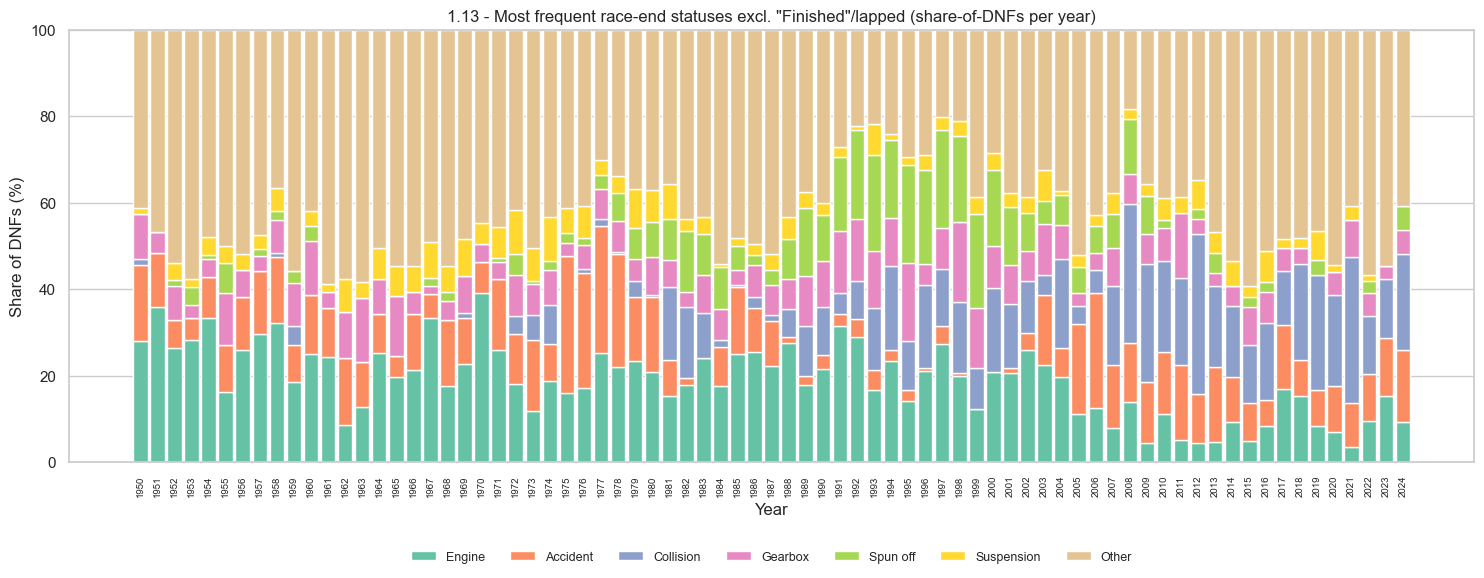

In [92]:
status_year = (
    results.merge(races[['raceId', 'year']], on='raceId')
           .merge(status, on='statusId')
)
# Pre-race administrative statuses - the driver entered the weekend but
# never started the race. Keep them out of the race-end story.
PRE_RACE_STATUSES = {'Did not qualify', 'Did not prequalify', '107% Rule'}

not_finished = status_year[
    (status_year['status'] != 'Finished')
    & (~status_year['status'].str.startswith('+'))
    & (~status_year['status'].isin(PRE_RACE_STATUSES))
].copy()

top6 = not_finished['status'].value_counts().head(6).index.tolist()
not_finished['status_grouped'] = not_finished['status'].where(
    not_finished['status'].isin(top6), 'Other'
)

pivot = (
    not_finished.groupby(['year', 'status_grouped']).size()
                .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

cols = [c for c in top6 if c in pivot_pct.columns]
if 'Other' in pivot_pct.columns:
    cols.append('Other')
pivot_pct = pivot_pct[cols]

palette = sns.color_palette('Set2', len(cols))

fig, ax = plt.subplots(figsize=(15, 6))
bottom = pd.Series(0.0, index=pivot_pct.index)
for col, color in zip(cols, palette):
    ax.bar(pivot_pct.index, pivot_pct[col], bottom=bottom,
           color=color, label=col, width=0.85)
    bottom = bottom + pivot_pct[col]

ax.set_xticks(pivot_pct.index)
ax.set_xticklabels(pivot_pct.index, rotation=90, fontsize=7)
ax.set_ylim(0, 100)
ax.set_ylabel('Share of DNFs (%)')
ax.set_xlabel('Year')
ax.set_title('1.13 - Most frequent race-end statuses excl. "Finished"/lapped (share-of-DNFs per year)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=len(cols), fontsize=9, frameon=False)
plt.tight_layout()
show_and_save('1.13_status_excl_finished_yoy.png')


---
## Key insights from this notebook

1. **Verstappen 2023 holds the all-time consecutive-win record at 10** — alone at the top of Chart 1.4. The 9-win tier (Ascari 1953, Vettel 2013) and the 7-win tier (Schumacher 2004, Rosberg 2016) sit below. One driver from one team usually carries each era's streak board.

2. **Pole-position counts are biased toward modern drivers** because seasons grew from **6 races in 1950 to 24 in 2024** — a 4× expansion. Comparing pole *counts* across eras is misleading; comparing pole *rates* (poles per race entered) would be fairer. Possible follow-up.

3. **Win rate by grid is the obvious chart, but the tail is where it gets interesting.** P1 wins **42.6%** of races, then a steep drop (P2 = 24%, P3 = 12%, P4 = 6%). The long tail is non-trivial: **37 wins from P10+**, **8 wins from P15+**, and the deepest grid slot ever to produce a winner is **P22**. Mostly wet-race + safety-car chaos.

4. **"Won from the pit lane" has never happened in F1 history — 0 instances ever** (Chart 1.11). The closest equivalent — *started last on the grid, finished on the podium* — is **more common in modern F1, not less**: only 5 of 15 instances are pre-2000, while **10 of 15 are from 2005 onward**. The mechanism also flipped — older entries were small-field/attrition outcomes; modern entries are **grid-penalty comebacks by fast cars** (Hamilton at Hungary 2014, Vettel at Abu Dhabi 2012, Räikkönen at Bahrain 2006). See Chart 1.10.